In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

sns.set_style("whitegrid")

### Tahap 2: Data Preprocessing

In [2]:
df = pd.read_excel('Online Retail.xlsx')
print(f"Jumlah baris sebelum pembersihan: {df.shape[0]}")
display(df.head(10))

Jumlah baris sebelum pembersihan: 541909


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [3]:
# Mengubah kolom tanggal menjadi tipe datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Membersihkan data dari nilai kosong pada CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# Membuang transaksi retur (Quantity atau UnitPrice yang bernilai negatif/nol)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(f"Jumlah baris setelah pembersihan: {df.shape[0]}")

Jumlah baris setelah pembersihan: 397884


### Tahap 3: Feature Engineering RFM

In [4]:
# Membuat metrik total harga per baris transaksi
df['TotalHarga'] = df['Quantity'] * df['UnitPrice']

# Menentukan tanggal acuan (satu hari setelah transaksi paling terakhir di dataset)
tanggal_acuan = df['InvoiceDate'].max() + timedelta(days=1)

# Menyatukan data berdasarkan pelanggan untuk membuat metrik R, F, dan M
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (tanggal_acuan - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalHarga': 'sum'                                      # Monetary
}).reset_index()

# Mengganti nama kolom agar lebih intuitif
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalHarga': 'Monetary'
}, inplace=True)

print("Tampilan awal data RFM:")
display(rfm.head(7))

Tampilan awal data RFM:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00


### Tahap 4: Standardisasi Data

In [5]:
# Memilih kolom yang akan distandarisasi (R, F, M)
fitur_rfm = rfm[['Recency', 'Frequency', 'Monetary']]

# Menyamakan skala angka menggunakan StandardScaler
scaler = StandardScaler()
rfm_skala = scaler.fit_transform(fitur_rfm) # <--- Hasilnya di sini adalah NumPy Array

# Menyimpan hasil skala ke dalam tabel baru (dikembalikan ke wujud DataFrame)
rfm_standar = pd.DataFrame(rfm_skala, columns=fitur_rfm.columns, index=rfm.index)

display(rfm_standar.head(7))

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347
5,-0.565349,0.484336,0.050263
6,1.114606,-0.425097,-0.218650


### Tahap 5: Penentuan Jumlah Cluster Optimal

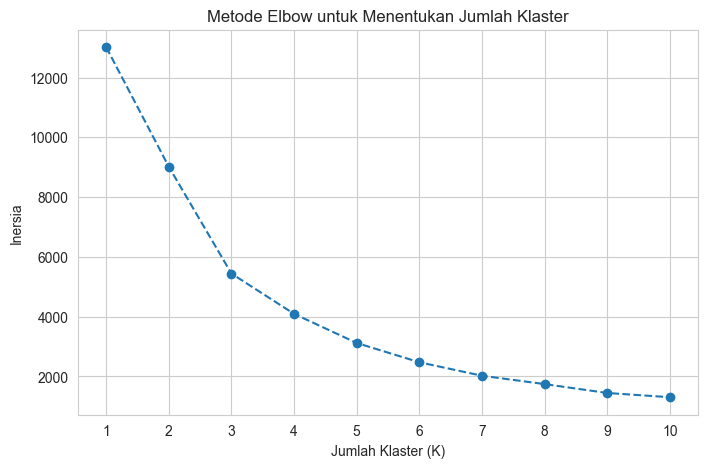

In [6]:
# Menggunakan metode Elbow untuk mencari K terbaik
inersia = []
rentang_k = range(1, 11)

for k in rentang_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_standar)
    inersia.append(kmeans.inertia_)

# Menampilkan grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(rentang_k, inersia, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inersia')
plt.xticks(rentang_k)
plt.show()

# Berdasarkan karakteristik dataset Retail UCI, membagi menjadi 4 klaster biasanya paling ideal untuk bisnis

### Tahap 6: K-Means Clustering

In [7]:
# Mengeksekusi K-Means dengan K=4
jumlah_klaster = 4
model_kmeans = KMeans(n_clusters=jumlah_klaster, random_state=42, n_init=10)

# Menempelkan hasil klaster ke tabel RFM utama
rfm['Klaster'] = model_kmeans.fit_predict(rfm_standar)

In [10]:
from sklearn.metrics import silhouette_score

# Menghitung Silhouette Score untuk model K-Means yang sudah dibuat
skor_siluet = silhouette_score(rfm_standar, rfm['Klaster'])

print(f"Evaluasi Model K-Means Clustering")
print(f"Jumlah Klaster (K) : {jumlah_klaster}")
print(f"Silhouette Score   : {skor_siluet:.3f}")

# Panduan membaca skor:
# > 0.5 : Struktur klaster sangat bagus dan terpisah jelas
# 0.2 - 0.5 : Struktur klaster lumayan, tapi ada sedikit tumpang tindih
# < 0.2 : Struktur klaster buruk atau data terlalu acak

Evaluasi Model K-Means Clustering
Jumlah Klaster (K) : 4
Silhouette Score   : 0.616


In [8]:
# Menganalisis rata-rata nilai R, F, dan M untuk setiap klaster
profil_klaster = rfm.groupby('Klaster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("Karakteristik setiap klaster:")
display(profil_klaster)

# Catatan Analisis (output belum fix)
# Klaster 0: R rendah, F sangat tinggi, M sangat tinggi -> Pelanggan Sultan (VIP)
# Klaster 1: R sangat tinggi, F rendah, M rendah -> Pelanggan Pasif / Hilang
# Klaster 2: R sedang, F sedang, M sedang -> Pelanggan Reguler
# Klaster 3: R rendah, F tinggi, M sedang -> Pelanggan Baru Potensial

Karakteristik setiap klaster:


Recency Frequency   Monetary      
           mean      mean       mean count
Klaster                                   
0         43.70      3.68    1359.05  3054
1        248.08      1.55     480.62  1067
2          7.38     82.54  127338.31    13
3         15.50     22.33   12709.09   204

### Tahap 8: Rule-Based Promotion Recommendation

In [9]:
# Menerapkan aturan bisnis berdasarkan karakteristik asli klaster
def berikan_rekomendasi(klaster):
    if klaster == 2:
        # Klaster 2: Sultan Tertinggi (Mega VIP) - 13 Orang
        return "Layanan B2B Prioritas & Account Manager Khusus (Tanpa Diskon)"
    
    elif klaster == 3:
        # Klaster 3: Pelanggan Setia (VIP) - 204 Orang
        return "Voucher Eksklusif Akses Awal Produk Baru & Reward Poin"
    
    elif klaster == 0:
        # Klaster 0: Pelanggan Reguler (Mayoritas) - 3054 Orang
        return "Voucher Bundling Beli 2 Gratis 1 (Tingkatkan Keranjang)"
    
    elif klaster == 1:
        # Klaster 1: Pelanggan Pasif / Hampir Hilang - 1067 Orang
        return "Voucher Diskon Rp100.000 (Kampanye Reaktivasi / Win-Back)"
    
    else:
        return "Promosi Reguler"

# Menerapkan aturan ke setiap pelanggan di dalam tabel
rfm['Rekomendasi_Promosi'] = rfm['Klaster'].apply(berikan_rekomendasi)

# Menampilkan 10 data teratas untuk memastikan kode berhasil
display(rfm[['CustomerID', 'Klaster', 'Rekomendasi_Promosi']].head(10))

,CustomerID,Klaster,Rekomendasi_Promosi
0,12346.0,3,Voucher Eksklusif Akses Awal Produk Baru & Rew...
1,12347.0,0,Voucher Bundling Beli 2 Gratis 1 (Tingkatkan K...
2,12348.0,0,Voucher Bundling Beli 2 Gratis 1 (Tingkatkan K...
3,12349.0,0,Voucher Bundling Beli 2 Gratis 1 (Tingkatkan K...
4,12350.0,1,Voucher Diskon Rp100.000 (Kampanye Reaktivasi ...
5,12352.0,0,Voucher Bundling Beli 2 Gratis 1 (Tingkatkan K...
6,12353.0,1,Voucher Diskon Rp100.000 (Kampanye Reaktivasi ...
7,12354.0,1,Voucher Diskon Rp100.000 (Kampanye Reaktivasi ...
8,12355.0,1,Voucher Diskon Rp100.000 (Kampanye Reaktivasi ...
9,12356.0,0,Voucher Bundling Beli 2 Gratis 1 (Tingkatkan K...


1. Klaster 2: "Sultan Tertinggi" (Mega VIP / B2B)
   - Karakter: Pengeluaran paling raksasa (M = 127.338), intensitas kedatangan paling tinggi (F = 82), dan baru saja bertransaksi (R = 7 hari).
   - Fakta Bisnis: Karena anggotanya cuma 13 orang, ini hampir bisa dipastikan bukan pembeli eceran biasa, melainkan perusahaan mitra (B2B), agen, atau pedagang grosir besar.

2. Klaster 3: Pelanggan Setia (VIP)
   - Karakter: Sangat rutin berbelanja (F = 22), pengeluaran besar (M = 12.709), dan sangat aktif (R = 15 hari).
   - Fakta Bisnis: Berisi 204 orang. Ini adalah pelanggan ritel terbaik dan paling loyal yang menjaga roda bisnis SmartVoucher tetap berputar stabil.

3. Klaster 0: Pelanggan Reguler (Mayoritas)
   - Karakter: Sesekali mampir (F = 3.6), nominal belanja wajar (M = 1.359), dan rata-rata terakhir datang sebulan lebih yang lalu (R = 43 hari).
   - Fakta Bisnis: Dengan total 3.054 orang, ini adalah cerminan masyarakat umum. Fokus strateginya adalah melakukan up-selling agar keranjang belanja mereka bertambah.

4. Klaster 1: Pelanggan Pasif (Churn)
   - Karakter: Sudah sangat lama menghilang (R = 248 hari alias lebih dari 8 bulan!), dan riwayat belanjanya sangat minim (F = 1.5).
   - Fakta Bisnis: Berisi 1.067 orang. Ini adalah "zona merah". Promosi untuk kelompok ini murni dirancang sebagai kampanye reaktivasi untuk "membangunkan" mereka kembali.

### Output Strategi Promosi

In [ ]:
# 1. Mengekspor tabel akhir ke format CSV untuk digunakan oleh frontend/dashboard
rfm.to_csv('hasil_rekomendasi_promosi.csv', index=False)
print("Tabel data pelanggan dan promosi berhasil disimpan ke 'hasil_rekomendasi_promosi.csv'.")

# 2. Mengekspor model K-Means dan Scaler agar bisa dipakai oleh backend Flask (Fase 2)
joblib.dump(model_kmeans, 'model_kmeans_promosi.pkl')
joblib.dump(scaler, 'scaler_rfm.pkl')
print("Model K-Means dan Scaler berhasil disimpan untuk tahap Backend.")

Tabel data pelanggan dan promosi berhasil disimpan ke 'hasil_rekomendasi_promosi.csv'.
Model K-Means dan Scaler berhasil disimpan untuk tahap Backend.
